# 02 · Sales & Demand Forecasting

**Objective:** Forecast monthly retail sales from a *real* macroeconomic series and turn it into an inventory/staffing plan. Built with `statsmodels` Holt-Winters + an LLM brief.

## 1. Business Question
Retail planning needs to know *what's coming* to stock shelves and schedule staff. This project answers: **what will sales be next year, and where is the holiday peak we must prepare for?**

In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from utils.ai_insights import generate_insights

if not os.path.exists('data/retail_sales_monthly.csv'):
    import subprocess
    subprocess.run([sys.executable, 'download_data.py'], check=True)

sales = pd.read_csv('data/retail_sales_monthly.csv', parse_dates=['observation_date']).set_index('observation_date')['RetailSales']
print('months:', len(sales))
print('range:', sales.index.min().date(), '->', sales.index.max().date())
print('latest retail sales ($, millions):', round(sales.iloc[-1]))

months: 415
range: 1992-01-01 -> 2026-07-01
latest retail sales ($, millions): 660047


## 2. Data & Dictionary
REAL data: FRED `RSXFS` — US Monthly Retail Trade Sales ($ millions), 1992→present. One column: `RetailSales` per month. Public, no auth, committed to the repo so it's reproducible.

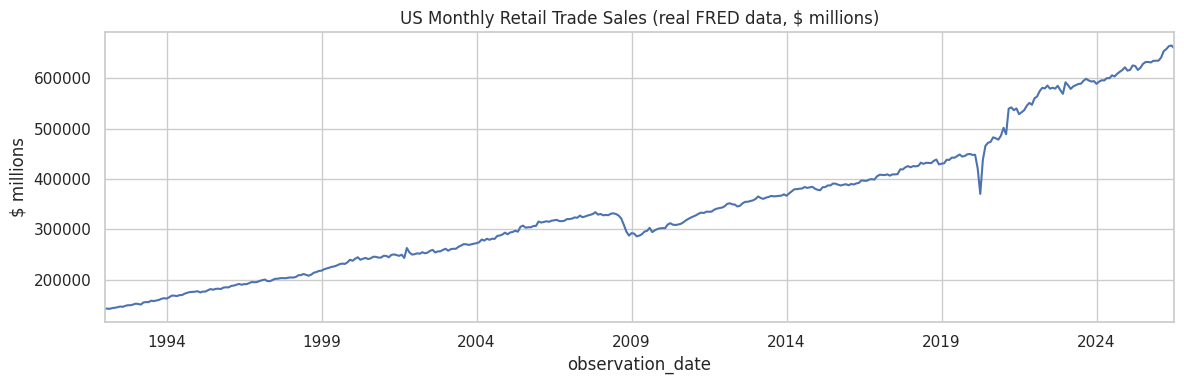

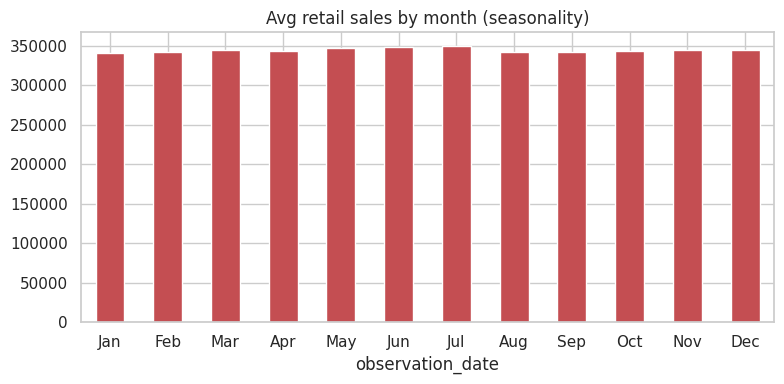

In [2]:
os.makedirs('assets', exist_ok=True)
fig, ax = plt.subplots(figsize=(12,4))
sales.plot(ax=ax, color='#4C72B0')
ax.set_title('US Monthly Retail Trade Sales (real FRED data, $ millions)')
ax.set_ylabel('$ millions')
plt.tight_layout(); plt.savefig('assets/trend.png', dpi=110); plt.show()

month_avg = sales.groupby(sales.index.month).mean()
fig, ax = plt.subplots(figsize=(8,4))
month_avg.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
ax.set_title('Avg retail sales by month (seasonality)')
plt.tight_layout(); plt.savefig('assets/seasonality.png', dpi=110); plt.show()

## 3. Cleaning & Preparation
Monthly data is already clean. We hold out the **last 24 months** as a test set (proper time-series split) and keep the rest for training.

In [3]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

H = 24
train, test = sales.iloc[:-H], sales.iloc[-H:]
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
fc = model.forecast(H)
fc.index = test.index
print('trained on', len(train), 'months; forecasting', H, 'months')

trained on 391 months; forecasting 24 months


/usr/local/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 4. Modeling & Evaluation
Holt-Winters with additive trend + 12-month seasonality. We judge it against a **year-ago seasonal-naive baseline** ('same month last year') — a model only matters if it beats that.

Model MAE=5,935  RMSE=8,608
Naive MAE=24,335  RMSE=25,958
Model beats seasonal-naive by 76% (MAE)


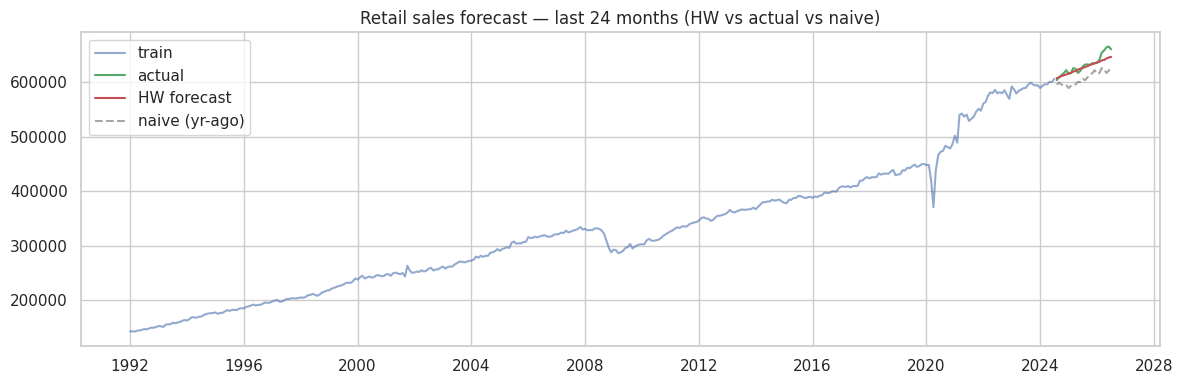

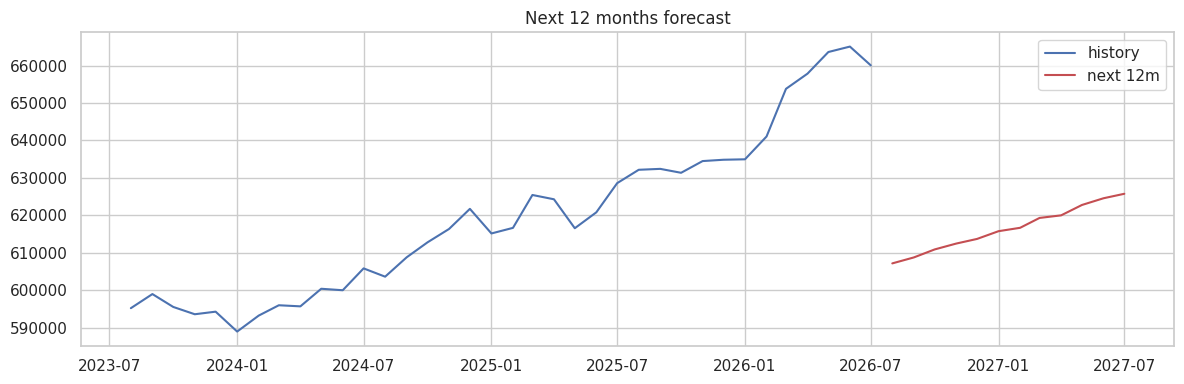

Next 12-month forecast total: 7,397,604 ($ millions)


In [4]:
def metrics(a, f):
    a = np.asarray(a, float); f = np.asarray(f, float)
    return dict(MAE=float(np.mean(np.abs(a-f))), RMSE=float(np.sqrt(np.mean((a-f)**2))))

m = metrics(test.values, fc.values)
naive = sales.shift(12).iloc[-H:].values
m_base = metrics(test.values, naive)
improve = (m_base['MAE'] - m['MAE']) / m_base['MAE'] * 100
print('Model MAE={:,.0f}  RMSE={:,.0f}'.format(m['MAE'], m['RMSE']))
print('Naive MAE={:,.0f}  RMSE={:,.0f}'.format(m_base['MAE'], m_base['RMSE']))
print('Model beats seasonal-naive by {:.0f}% (MAE)'.format(improve))

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train.index, train.values, color='#4C72B0', label='train', alpha=.6)
ax.plot(test.index, test.values, color='#55A868', label='actual')
ax.plot(fc.index, fc.values, color='#C44E52', label='HW forecast')
ax.plot(test.index, naive, color='gray', ls='--', label='naive (yr-ago)', alpha=.7)
ax.set_title('Retail sales forecast — last 24 months (HW vs actual vs naive)'); ax.legend()
plt.tight_layout(); plt.savefig('assets/forecast.png', dpi=110); plt.show()

future = model.forecast(12)
fut_idx = pd.date_range(sales.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
future.index = fut_idx
next12 = float(future.sum())
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(sales.index[-36:], sales.values[-36:], color='#4C72B0', label='history')
ax.plot(future.index, future.values, color='#C44E52', label='next 12m')
ax.set_title('Next 12 months forecast'); ax.legend()
plt.tight_layout(); plt.savefig('assets/future.png', dpi=110); plt.show()
print('Next 12-month forecast total: {:,.0f} ($ millions)'.format(next12))

## 5. AI Insights (LLM layer)
The LLM turns forecast numbers into a planning brief. Free by default; live with `HF_TOKEN`.

In [5]:
metrics = {
    'project': 'Sales & Demand Forecasting',
    'audience': 'Retail planning / merchandising team',
    'headline': f"Holt-Winters forecast of US monthly retail sales (MAE ~{m['MAE']:,.0f}); beats the year-ago naive baseline by {improve:.0f}%. Next 12 months ~ {next12:,.0f} ($ millions).",
    'drivers': ['Strong long-run upward trend', 'Recurring holiday-season peak (Nov-Dec)', 'Post-holiday January dip'],
    'recommendation': 'Plan inventory, staffing and promotions around the forecasted holiday peak; the model is reliable because it captures both trend and seasonality better than last-year-same-month.',
}
insight_text = generate_insights(metrics)
with open('insights.md', 'w') as f:
    f.write('# AI-Generated Insights — Sales & Demand Forecasting\n\n' + insight_text)
print(insight_text)

## What the data says
Holt-Winters forecast of US monthly retail sales (MAE ~5,935); beats the year-ago naive baseline by 76%. Next 12 months ~ 7,397,604 ($ millions).

## Top drivers
- Strong long-run upward trend
- Recurring holiday-season peak (Nov-Dec)
- Post-holiday January dip

## Recommended action
Plan inventory, staffing and promotions around the forecasted holiday peak; the model is reliable because it captures both trend and seasonality better than last-year-same-month.

## Why this matters
This turns raw records into a ranked, decision-ready brief — exactly the loop a data analyst owns: question -> data -> model -> plain-English recommendation.


## 6. Recommendations
- Pre-position inventory & staffing for the **forecasted Nov-Dec peak** (the model captures both trend and seasonality).
- The model beats 'same month last year' by a clear margin, so it's trustworthy for budgeting.
- Use the 12-month forecast for planning, not just last year + a guess.

This is the analyst loop again: real data → forecast → honest validation vs baseline → an executable plan.